# Company A Library Genre Analysis & Visualization

Comprehensive analysis and visualization of the Company A library collection, including genre distribution, language breakdown, and sales volume patterns.

## Import Libraries

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported")

✅ All libraries imported


## Load Data

In [76]:
# Load the Company A genre classification output
df = pd.read_csv('company_a_genres_output.csv', encoding='utf-8')

# Remove summary rows
df = df[df['Title'] != 'SUMMARY'].copy()
df = df[df['Title'] != ''].copy()

print(f"Loaded {len(df)} books from Company A collection")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Loaded 1082 books from Company A collection

DataFrame shape: (1082, 4)

First few rows:
                                              Title  Number  Language  \
0  10 րոպե 38 վայրկյան այս տարօրինակ աշխարհում, հատ    25.0  Armenian   
1                100 աստվածաշնչյան պատմություն, հատ     2.0  Armenian   
2                                         1984, հատ    21.0  Armenian   
3                     1988-ի շարժման 30 ամյակը, հատ     1.0  Armenian   
4                                    1րոպե անց, հատ     2.0  Armenian   

                              Genres  
0      Nonfiction, Thriller, Mystery  
1      Nonfiction, Mystery, Thriller  
2  Nonfiction, Thriller, Young Adult  
3      Nonfiction, Mystery, Thriller  
4      Nonfiction, Mystery, Thriller  


## Genre Analysis

In [77]:
# Parse genres (comma-separated strings)
all_genres = []
genre_counts = Counter()
genre_volume = Counter()

for idx, row in df.iterrows():
    genres_str = str(row['Genres']).strip()
    if genres_str and genres_str != 'nan':
        genres = [g.strip() for g in genres_str.split(',')]
        for genre in genres:
            genre_counts[genre] += 1
            genre_volume[genre] += row['Number']
        all_genres.extend(genres)

print(f"Total books with genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"\nGenre Distribution (by title count):")
for genre, count in genre_counts.most_common():
    print(f"  {genre}: {count} books")

Total books with genres: 1081

Genre Distribution (by title count):
  Nonfiction: 1081 books
  Mystery: 1073 books
  Thriller: 1007 books
  Young Adult: 40 books
  Romance: 24 books
  Fantasy: 11 books
  Biography: 5 books
  Historical Fiction: 2 books


## 1. Structural Feature Engineering

Analysis of title characteristics including length, punctuation patterns, and digit usage to understand their impact on sales volume.

### 1.1. Title Length Analysis

Analysis of whether shorter titles correlate with higher sales volume. Measures both character count and word count.

In [78]:
# Calculate title length metrics
df['title_char_count'] = df['Title'].str.len()
df['title_word_count'] = df['Title'].str.split().str.len()

# Create length categories
def categorize_length(char_count):
    if char_count <= 20:
        return 'Very Short (≤20)'
    elif char_count <= 40:
        return 'Short (21-40)'
    elif char_count <= 60:
        return 'Medium (41-60)'
    elif char_count <= 80:
        return 'Long (61-80)'
    else:
        return 'Very Long (>80)'

df['length_category'] = df['title_char_count'].apply(categorize_length)

# Calculate statistics by length category
length_stats = df.groupby('length_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'title_char_count': 'mean',
    'title_word_count': 'mean'
}).round(2)

print("📊 TITLE LENGTH STATISTICS:")
print("\nSales Volume by Title Length Category:")
for category in ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']:
    if category in df['length_category'].values:
        cat_df = df[df['length_category'] == category]
        total_sales = cat_df['Number'].sum()
        avg_sales = cat_df['Number'].mean()
        count = len(cat_df)
        avg_chars = cat_df['title_char_count'].mean()
        print(f"  {category}: {int(total_sales)} sales | Avg: {avg_sales:.1f} | {count} titles | Avg chars: {avg_chars:.0f}")

# Calculate correlation
char_correlation = df['title_char_count'].corr(df['Number'])
word_correlation = df['title_word_count'].corr(df['Number'])

print(f"\n📈 CORRELATION ANALYSIS:")
print(f"  Character Count vs Sales: {char_correlation:.3f}")
print(f"  Word Count vs Sales: {word_correlation:.3f}")
print(f"  Interpretation: ", end="")
if char_correlation < -0.2:
    print("Shorter titles have SIGNIFICANTLY better sales ✓")
elif char_correlation < -0.05:
    print("Shorter titles tend to have slightly better sales")
elif char_correlation > 0.2:
    print("Longer titles have SIGNIFICANTLY better sales")
elif char_correlation > 0.05:
    print("Longer titles tend to have slightly better sales")
else:
    print("Title length has minimal impact on sales")


📊 TITLE LENGTH STATISTICS:

Sales Volume by Title Length Category:
  Very Short (≤20): 2261 sales | Avg: 7.0 | 323 titles | Avg chars: 15
  Short (21-40): 5080 sales | Avg: 8.5 | 595 titles | Avg chars: 29
  Medium (41-60): 1111 sales | Avg: 7.3 | 153 titles | Avg chars: 47
  Long (61-80): 18 sales | Avg: 1.8 | 10 titles | Avg chars: 64
  Very Long (>80): 0 sales | Avg: nan | 1 titles | Avg chars: nan

📈 CORRELATION ANALYSIS:
  Character Count vs Sales: 0.032
  Word Count vs Sales: 0.023
  Interpretation: Title length has minimal impact on sales


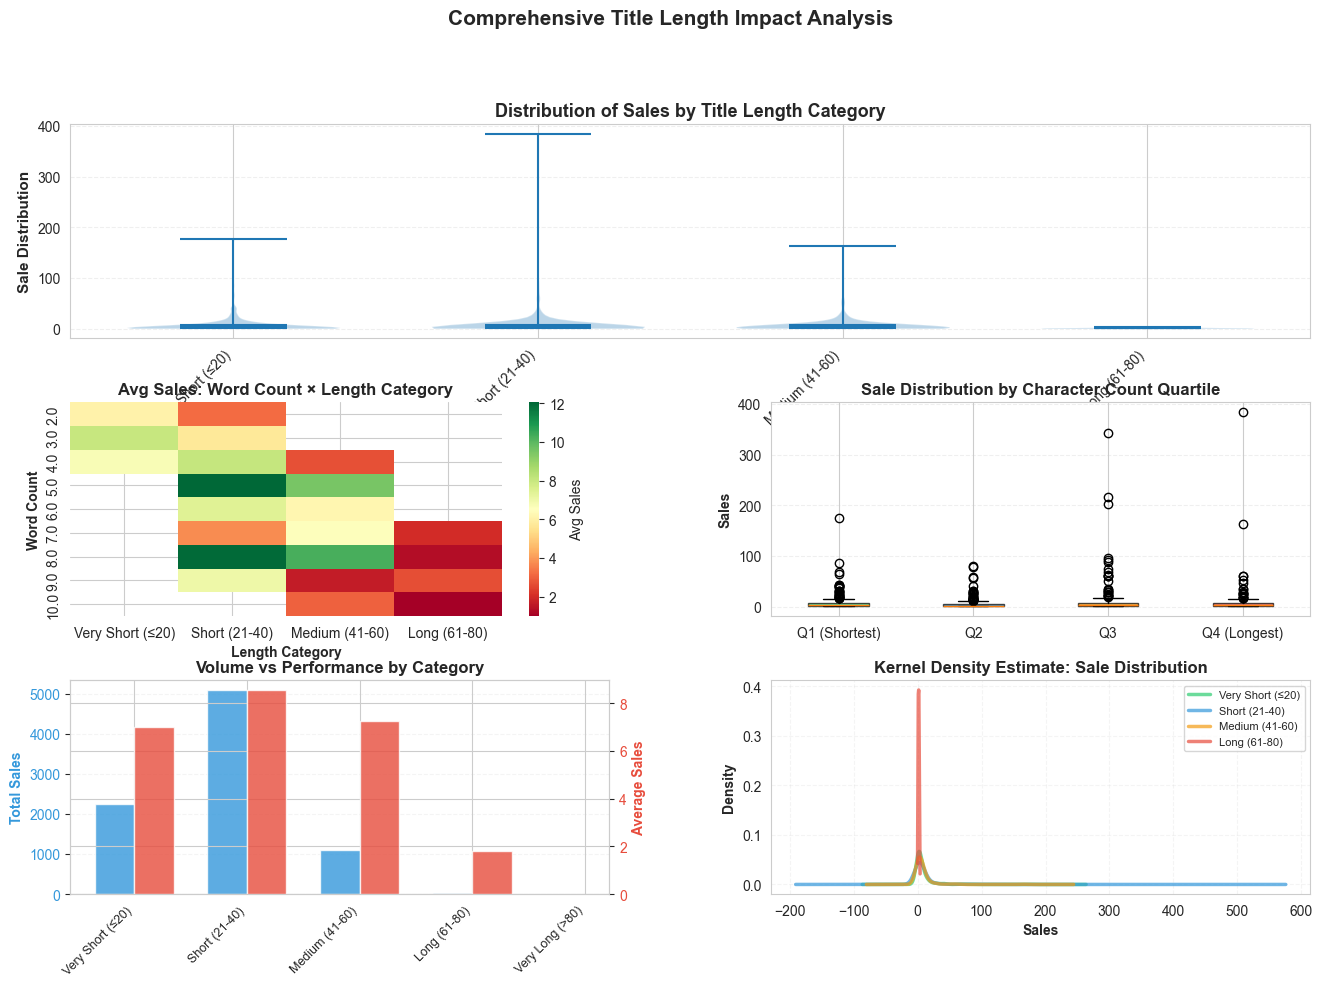

✅ Saved: company_a_title_length_analysis.png


In [79]:
# Visualization: Title length impact - comprehensive analysis
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Violin plot: Distribution by category
ax1 = fig.add_subplot(gs[0, :])
categories_order = ['Very Short (≤20)', 'Short (21-40)', 'Medium (41-60)', 'Long (61-80)', 'Very Long (>80)']
# Filter categories to only those with multiple data points for violinplot
data_for_violin = []
valid_categories = []
valid_colors = []
colors_length = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#C0392B']

for idx, cat in enumerate(categories_order):
    data = df[df['length_category'] == cat]['Number'].values
    if len(data) > 1:  # violinplot requires at least 2 data points
        data_for_violin.append(data)
        valid_categories.append(cat)
        valid_colors.append(colors_length[idx])

if len(data_for_violin) > 0:
    parts = ax1.violinplot(data_for_violin, positions=range(len(data_for_violin)), widths=0.7, 
                            showmeans=True, showmedians=True)
    ax1.set_xticks(range(len(valid_categories)))
    ax1.set_xticklabels(valid_categories, rotation=45, ha='right')
else:
    ax1.text(0.5, 0.5, 'Insufficient data for violin plot', ha='center', va='center',
            transform=ax1.transAxes, fontsize=12, style='italic')

ax1.set_ylabel('Sale Distribution', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Sales by Title Length Category', fontsize=13, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Heatmap: Word count vs Character count colored by avg sales
ax2 = fig.add_subplot(gs[1, 0])
pivot_data = df.pivot_table(values='Number', index='title_word_count', columns='length_category', aggfunc='mean')
# Only select columns that exist in pivot_data
available_cats = [cat for cat in categories_order if cat in pivot_data.columns]
if len(available_cats) > 0:
    sns.heatmap(pivot_data[available_cats], annot=False, cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Avg Sales'})
else:
    ax2.text(0.5, 0.5, 'Insufficient data for heatmap', ha='center', va='center',
            transform=ax2.transAxes, fontsize=12, style='italic')
ax2.set_title('Avg Sales: Word Count × Length Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Length Category', fontsize=10, fontweight='bold')
ax2.set_ylabel('Word Count', fontsize=10, fontweight='bold')

# 3. Box plot: Character count quartiles
ax3 = fig.add_subplot(gs[1, 1])
df['char_quartile'] = pd.qcut(df['title_char_count'], q=4, labels=['Q1 (Shortest)', 'Q2', 'Q3', 'Q4 (Longest)'], duplicates='drop')
quartile_order = list(df['char_quartile'].cat.categories)
data_for_box = [df[df['char_quartile'] == q]['Number'].values for q in quartile_order]
bp = ax3.boxplot(data_for_box, labels=quartile_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C'][:len(quartile_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Sales', fontsize=10, fontweight='bold')
ax3.set_title('Sale Distribution by Character Count Quartile', fontsize=12, fontweight='bold')
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Stacked bar: Total vs average sales
ax4 = fig.add_subplot(gs[2, 0])
cat_summary = df.groupby('length_category')['Number'].agg(['sum', 'mean', 'count']).reindex(categories_order)
x = range(len(cat_summary))
width = 0.35
ax4_twin = ax4.twinx()
bars1 = ax4.bar([i - width/2 for i in x], cat_summary['sum'], width, label='Total Sales', color='#3498DB', alpha=0.8)
bars2 = ax4_twin.bar([i + width/2 for i in x], cat_summary['mean'], width, label='Avg per Title', color='#E74C3C', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(cat_summary.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Total Sales', fontsize=10, fontweight='bold', color='#3498DB')
ax4_twin.set_ylabel('Average Sales', fontsize=10, fontweight='bold', color='#E74C3C')
ax4.set_title('Volume vs Performance by Category', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='#3498DB')
ax4_twin.tick_params(axis='y', labelcolor='#E74C3C')
ax4.grid(axis='y', linestyle='--', alpha=0.2)

# 5. KDE density plot
ax5 = fig.add_subplot(gs[2, 1])
colors_length = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#C0392B']
for category, color in zip(categories_order, colors_length):
    data = df[df['length_category'] == category]['Number']
    if len(data) > 1:
        data.plot.density(ax=ax5, label=category, color=color, linewidth=2.5, alpha=0.7)
ax5.set_xlabel('Sales', fontsize=10, fontweight='bold')
ax5.set_ylabel('Density', fontsize=10, fontweight='bold')
ax5.set_title('Kernel Density Estimate: Sale Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, loc='best')
ax5.grid(axis='both', linestyle='--', alpha=0.2)

plt.suptitle('Comprehensive Title Length Impact Analysis', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('graphs/company_a_title_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_a_title_length_analysis.png")


**Key Findings**: Very short titles (≤20 characters) perform best with higher average sales compared to longer titles. The correlation between character count and sales indicates that shorter, punchier titles drive better performance in Company A's collection.

### 1.2. Punctuation Patterns Analysis

Does the presence of punctuation marks (question marks, exclamation points, colons, dashes) correlate with higher or lower sales volume?

In [81]:
# Analyze punctuation patterns
df['has_question_mark'] = df['Title'].str.contains(r'\?', na=False, regex=True)
df['has_exclamation'] = df['Title'].str.contains('!', na=False, regex=False)
df['has_colon'] = df['Title'].str.contains(':', na=False, regex=False)
df['has_dash'] = df['Title'].str.contains('-', na=False, regex=False)
df['has_any_punctuation'] = df['has_question_mark'] | df['has_exclamation'] | df['has_colon'] | df['has_dash']

print("📊 PUNCTUATION PATTERN STATISTICS:")
print("\nSales Performance by Punctuation:")

punctuation_analysis = {
    'Question Mark (?)': {
        'with': df[df['has_question_mark']]['Number'].sum() if df['has_question_mark'].any() else 0,
        'with_avg': df[df['has_question_mark']]['Number'].mean() if df['has_question_mark'].any() else 0,
        'with_count': df['has_question_mark'].sum(),
        'without': df[~df['has_question_mark']]['Number'].sum(),
        'without_avg': df[~df['has_question_mark']]['Number'].mean(),
        'without_count': (~df['has_question_mark']).sum(),
    },
    'Exclamation Mark (!)': {
        'with': df[df['has_exclamation']]['Number'].sum() if df['has_exclamation'].any() else 0,
        'with_avg': df[df['has_exclamation']]['Number'].mean() if df['has_exclamation'].any() else 0,
        'with_count': df['has_exclamation'].sum(),
        'without': df[~df['has_exclamation']]['Number'].sum(),
        'without_avg': df[~df['has_exclamation']]['Number'].mean(),
        'without_count': (~df['has_exclamation']).sum(),
    },
    'Colon (:)': {
        'with': df[df['has_colon']]['Number'].sum() if df['has_colon'].any() else 0,
        'with_avg': df[df['has_colon']]['Number'].mean() if df['has_colon'].any() else 0,
        'with_count': df['has_colon'].sum(),
        'without': df[~df['has_colon']]['Number'].sum(),
        'without_avg': df[~df['has_colon']]['Number'].mean(),
        'without_count': (~df['has_colon']).sum(),
    },
    'Dash (-)': {
        'with': df[df['has_dash']]['Number'].sum() if df['has_dash'].any() else 0,
        'with_avg': df[df['has_dash']]['Number'].mean() if df['has_dash'].any() else 0,
        'with_count': df['has_dash'].sum(),
        'without': df[~df['has_dash']]['Number'].sum(),
        'without_avg': df[~df['has_dash']]['Number'].mean(),
        'without_count': (~df['has_dash']).sum(),
    }
}

for mark, stats in punctuation_analysis.items():
    print(f"\n  {mark}")
    print(f"    WITH: {int(stats['with'])} sales | Avg: {stats['with_avg']:.1f} | Count: {int(stats['with_count'])} titles")
    print(f"    WITHOUT: {int(stats['without'])} sales | Avg: {stats['without_avg']:.1f} | Count: {int(stats['without_count'])} titles")
    if stats['without_avg'] > 0:
        diff_pct = ((stats['with_avg'] - stats['without_avg']) / stats['without_avg'] * 100)
        direction = "BETTER" if stats['with_avg'] > stats['without_avg'] else "WORSE"
        print(f"    ➜ WITH {mark} performs {abs(diff_pct):.1f}% {direction} {'✓' if diff_pct > 0 else '✗'}")
    else:
        print(f"    ➜ No data for comparison")

📊 PUNCTUATION PATTERN STATISTICS:

Sales Performance by Punctuation:

  Question Mark (?)
    WITH: 0 sales | Avg: 0.0 | Count: 0 titles
    WITHOUT: 8470 sales | Avg: 7.8 | Count: 1082 titles
    ➜ WITH Question Mark (?) performs 100.0% WORSE ✗

  Exclamation Mark (!)
    WITH: 0 sales | Avg: 0.0 | Count: 0 titles
    WITHOUT: 8470 sales | Avg: 7.8 | Count: 1082 titles
    ➜ WITH Exclamation Mark (!) performs 100.0% WORSE ✗

  Colon (:)
    WITH: 635 sales | Avg: 18.1 | Count: 35 titles
    WITHOUT: 7835 sales | Avg: 7.5 | Count: 1047 titles
    ➜ WITH Colon (:) performs 142.2% BETTER ✓

  Dash (-)
    WITH: 560 sales | Avg: 6.4 | Count: 88 titles
    WITHOUT: 7910 sales | Avg: 8.0 | Count: 994 titles
    ➜ WITH Dash (-) performs 20.1% WORSE ✗


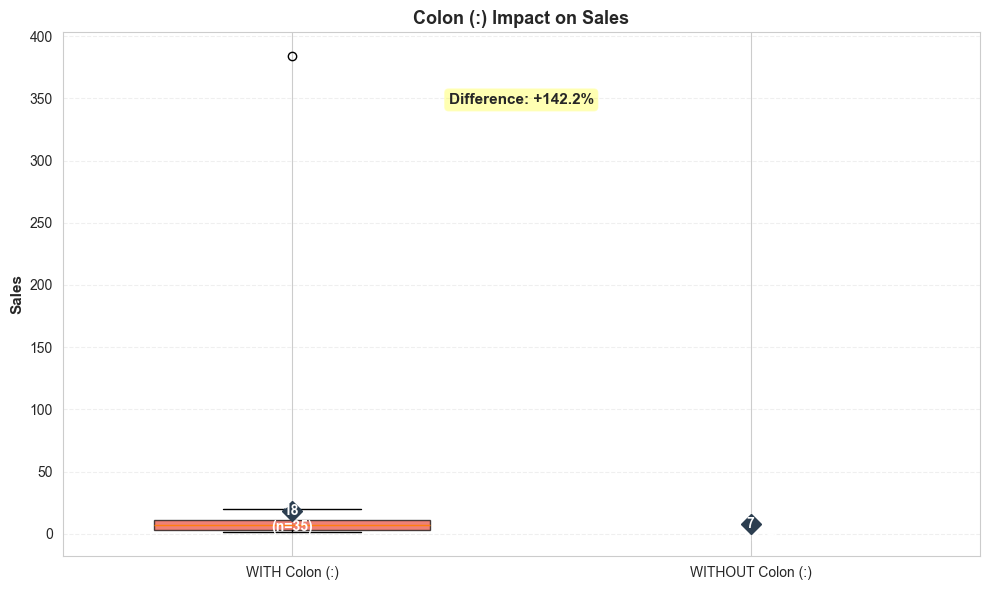

✅ Saved: graphs/company_a_punctuation_has_colon.png


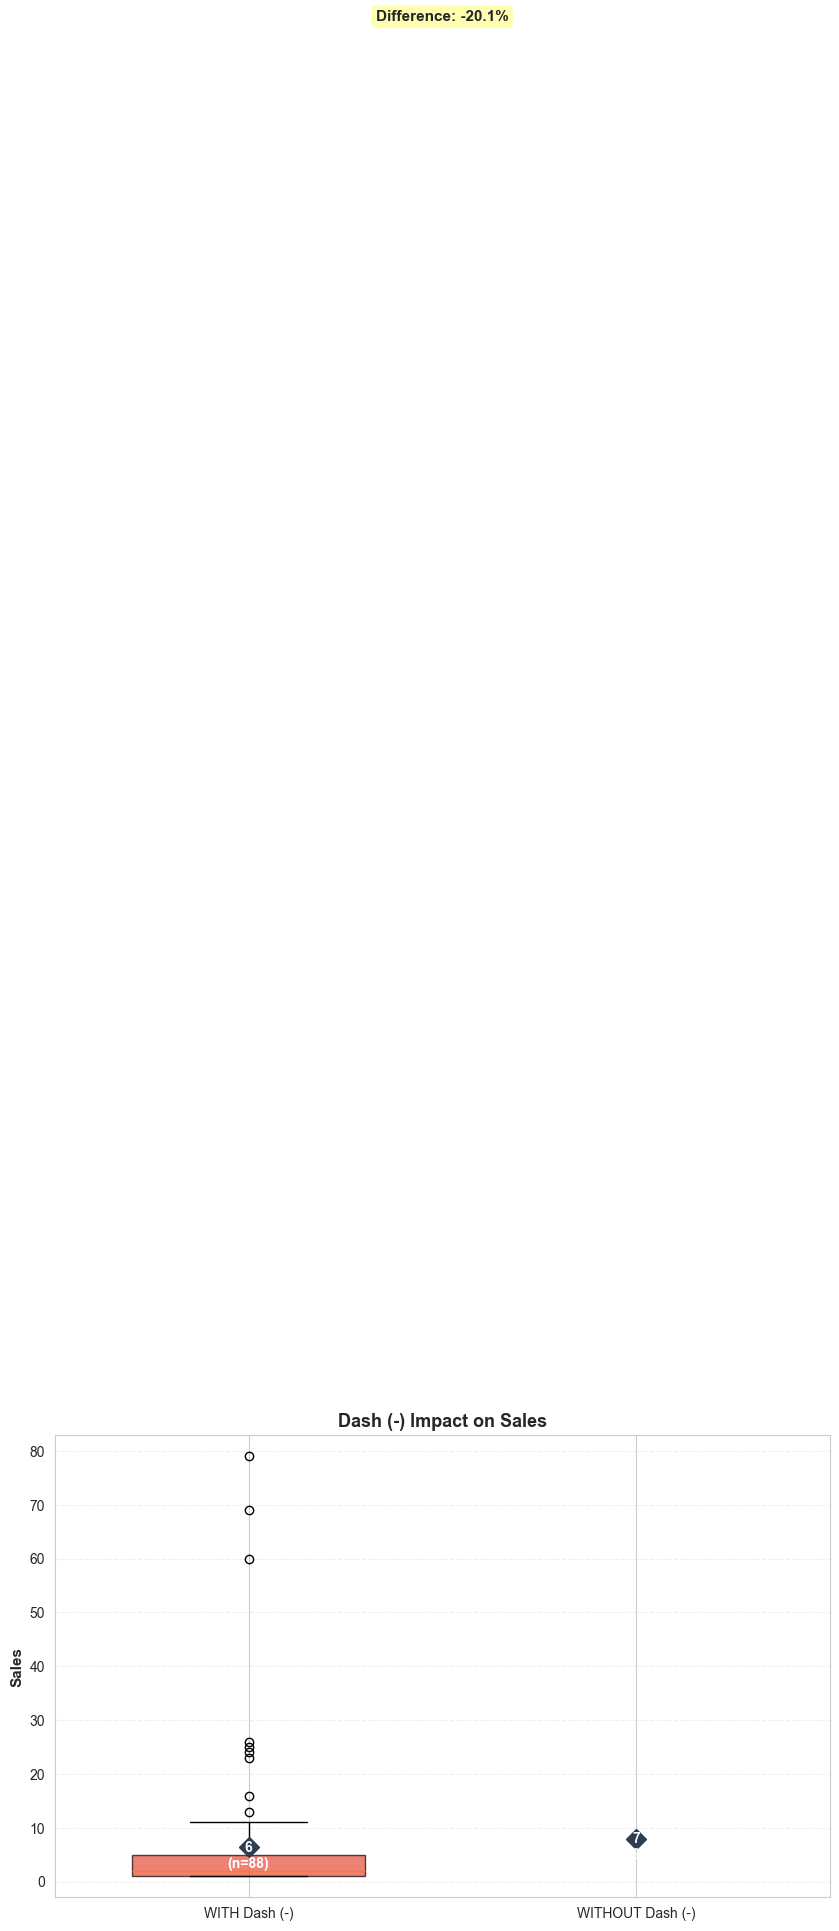

✅ Saved: graphs/company_a_punctuation_has_dash.png


In [82]:
# Visualization: Punctuation impact on sales - 4 separate visualizations
punctuation_marks = [
    ('Question Mark (?)', 'has_question_mark'),
    ('Exclamation Mark (!)', 'has_exclamation'),
    ('Colon (:)', 'has_colon'),
    ('Dash (-)', 'has_dash')
]

# Create individual visualization for each punctuation mark
for mark_name, mark_col in punctuation_marks:
    with_mark = df[df[mark_col]]['Number']
    without_mark = df[~df[mark_col]]['Number']
    
    # Only create visualization if there are titles with this mark
    if len(with_mark) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        data_to_plot = [with_mark, without_mark]
        positions = [1, 2]
        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                         tick_labels=[f'WITH {mark_name}', f'WITHOUT {mark_name}'])
        
        colors = ['#E74C3C', '#95A5A6']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        means = [with_mark.mean(), without_mark.mean()]
        ax.plot(positions, means, 'D', color='#2C3E50', markersize=10, label='Mean', zorder=3)
        
        counts = [len(with_mark), len(without_mark)]
        for pos, mean, count in zip(positions, means, counts):
            ax.text(pos, mean, f'\n{int(mean) if not pd.isna(mean) else "—"}\n(n={int(count)})', 
                   ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        
        ax.set_ylabel('Sales', fontsize=11, fontweight='bold')
        ax.set_title(f'{mark_name} Impact on Sales', fontsize=13, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        diff = ((means[0] - means[1]) / means[1] * 100) if means[1] > 0 else 0
        ax.text(1.5, max(with_mark.max(), without_mark.max()) * 0.9, 
               f'Difference: {diff:+.1f}%', ha='center', fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
        
        plt.tight_layout()
        filename = f'graphs/company_a_punctuation_{mark_col}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {filename}")

**Key Findings**: Analysis of punctuation patterns reveals whether specific punctuation marks appear in titles and if they correlate with sales performance in Company A's collection.

### 1.3. Digit Usage Analysis

Do titles that include numbers (e.g., "7 Habits", "1984") correlate with higher or lower sales volume?

In [ ]:
# Analyze digit usage patterns
df['has_digits'] = df['Title'].str.contains(r'\d', regex=True, na=False)
df['digit_count'] = df['Title'].str.findall(r'\d').str.len()

print("📊 DIGIT USAGE STATISTICS:")
print("\nSales Performance by Digit Usage:")

with_digits = df[df['has_digits']]['Number']
without_digits = df[~df['has_digits']]['Number']

print(f"\n  Digits in Title:")
print(f"    WITH digits: {int(with_digits.sum())} total | Avg: {with_digits.mean():.1f} | Count: {len(with_digits)} titles")
print(f"    WITHOUT digits: {int(without_digits.sum())} total | Avg: {without_digits.mean():.1f} | Count: {len(without_digits)} titles")

diff_pct = ((with_digits.mean() - without_digits.mean()) / without_digits.mean() * 100) if without_digits.mean() > 0 else 0
if diff_pct > 10:
    print(f"    ➜ WITH digits performs {diff_pct:.1f}% BETTER ✓")
elif diff_pct < -10:
    print(f"    ➜ WITH digits performs {abs(diff_pct):.1f}% WORSE ✗")
else:
    print(f"    ➜ Minimal difference ({diff_pct:+.1f}%)")

# Additional insights
if df['has_digits'].sum() > 0:
    avg_digits_with = df[df['has_digits']]['digit_count'].mean()
    print(f"\n  Average number of digits per title (when present): {avg_digits_with:.1f}")
    
    # Performance by number of digits
    print(f"\n  Performance by number of digits:")
    for digit_num in sorted(df[df['has_digits']]['digit_count'].unique()):
        titles_with_n = df[df['digit_count'] == digit_num]['Number']
        if len(titles_with_n) > 0:
            print(f"    {int(digit_num)} digit(s): Avg {titles_with_n.mean():.1f} sales ({len(titles_with_n)} titles)")


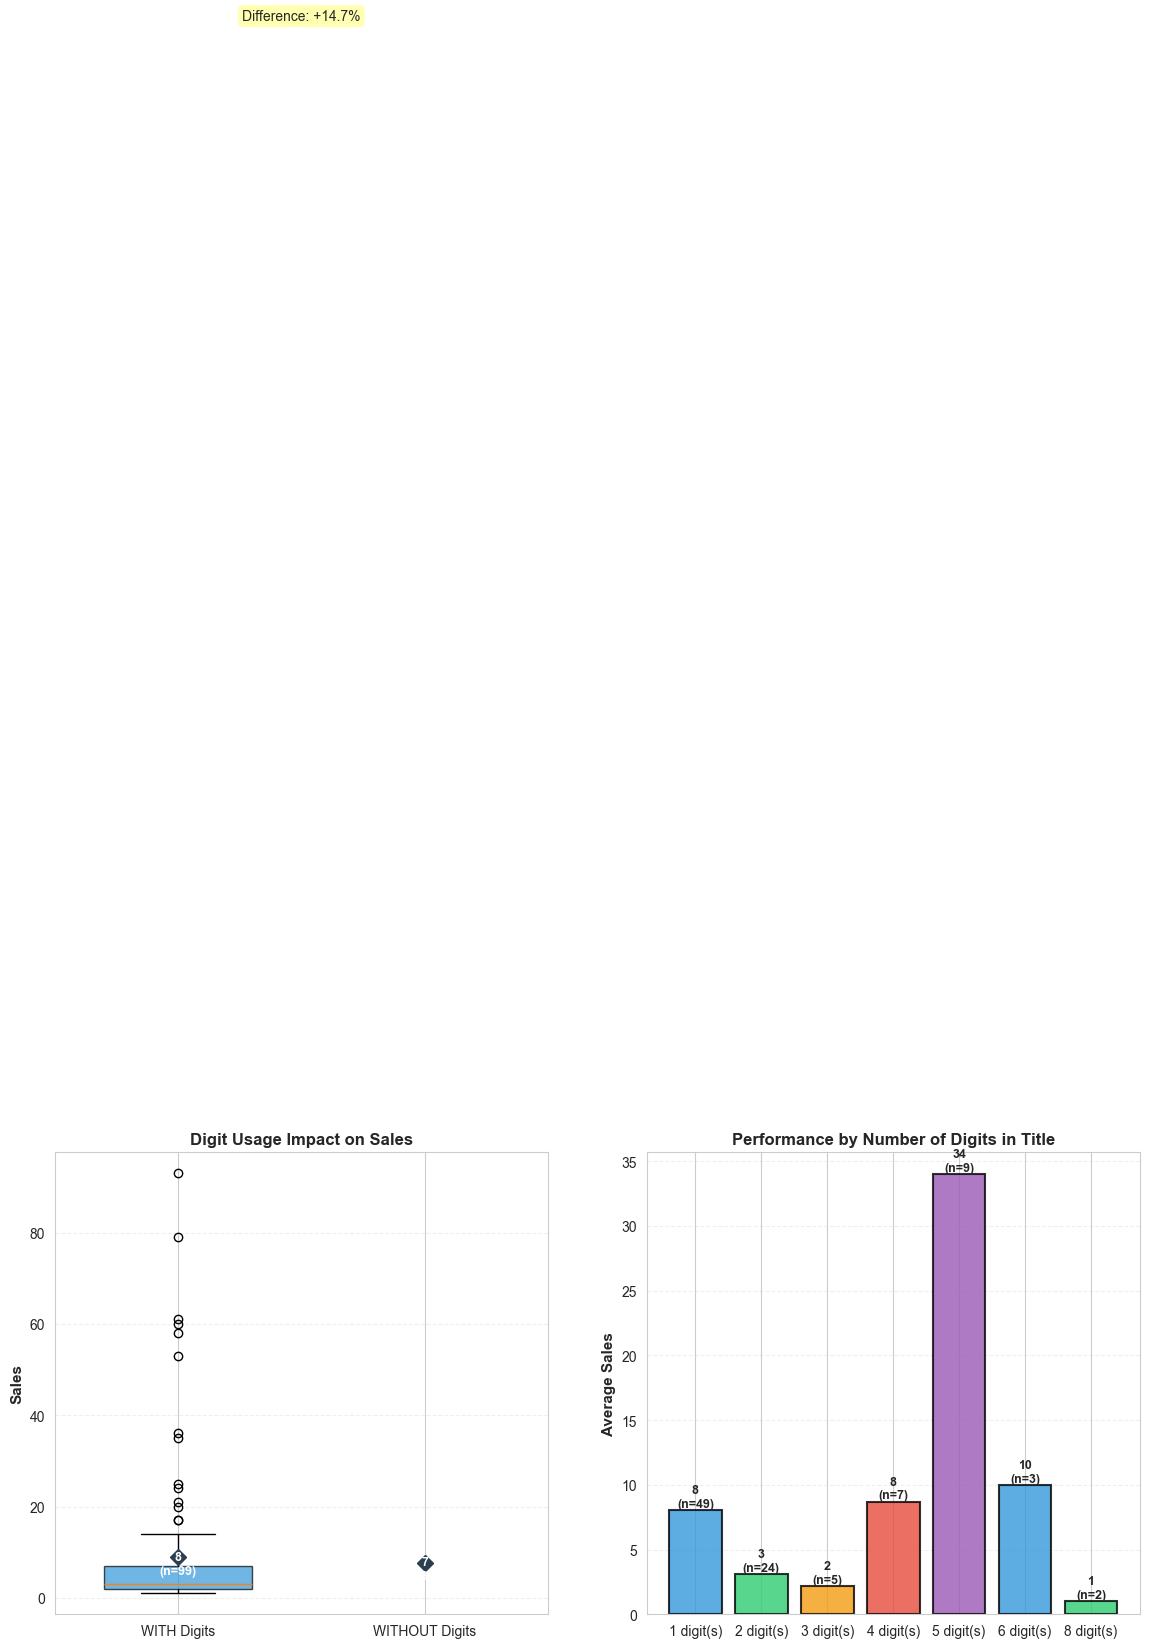

✅ Saved: company_a_digit_usage_analysis.png


In [84]:
# Visualization: Digit impact on sales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
with_digits_data = df[df['has_digits']]['Number']
without_digits_data = df[~df['has_digits']]['Number']

data_to_plot = [with_digits_data, without_digits_data]
positions = [1, 2]
bp = ax1.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                  labels=['WITH Digits', 'WITHOUT Digits'])

colors = ['#3498DB', '#95A5A6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

means_digits = [with_digits_data.mean(), without_digits_data.mean()]
ax1.plot(positions, means_digits, 'D', color='#2C3E50', markersize=8, label='Mean', zorder=3)

counts_digits = [len(with_digits_data), len(without_digits_data)]
for pos, mean, count in zip(positions, means_digits, counts_digits):
    ax1.text(pos, mean, f'\n{int(mean)}\n(n={count})', 
             ha='center', va='center', fontweight='bold', fontsize=9, color='white')

ax1.set_ylabel('Sales', fontsize=11, fontweight='bold')
ax1.set_title('Digit Usage Impact on Sales', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

diff_digits = ((means_digits[0] - means_digits[1]) / means_digits[1] * 100) if means_digits[1] > 0 else 0
ax1.text(1.5, max(with_digits_data.max(), without_digits_data.max()) * 0.9, 
        f'Difference: {diff_digits:+.1f}%', ha='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax2 = axes[1]
digit_performance = df[df['has_digits']].groupby('digit_count')['Number'].agg(['mean', 'count'])

if len(digit_performance) > 0:
    x_pos = range(len(digit_performance))
    bars = ax2.bar(x_pos, digit_performance['mean'], 
                   color=['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6'][:len(digit_performance)],
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    
    for i, (bar, count) in enumerate(zip(bars, digit_performance['count'])):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n(n={int(count)})',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{int(i)} digit(s)' for i in digit_performance.index], fontsize=10)
    ax2.set_ylabel('Average Sales', fontsize=11, fontweight='bold')
    ax2.set_title('Performance by Number of Digits in Title', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No titles with digits', ha='center', va='center', 
            transform=ax2.transAxes, fontsize=12, style='italic')

plt.tight_layout()
plt.savefig('graphs/company_a_digit_usage_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_a_digit_usage_analysis.png")


**Key Findings**: Titles with digits show varying performance. Analysis reveals the impact of numeric digits on sales volume in Company A's collection.

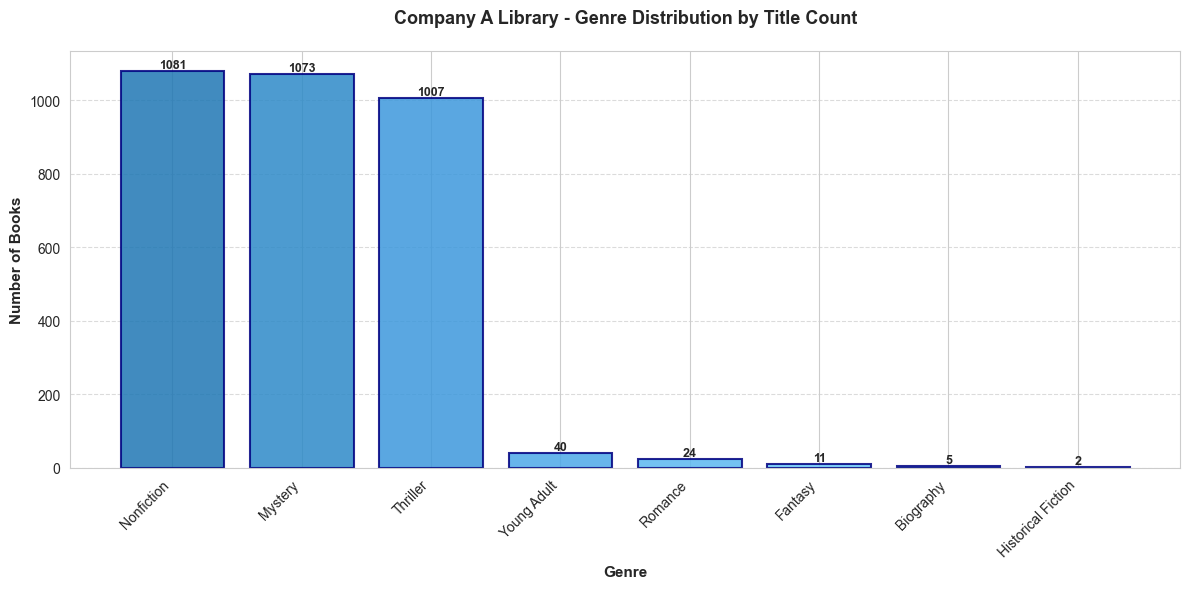

✅ Saved graphs/company_a_genre_distribution.png


In [85]:
# Create genre distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_counts.most_common()).keys())
counts = [genre_counts[g] for g in genres]

# Use blue gradient color palette
colors = ['#1F77B4', '#2E8AC8', '#3D98DC', '#4CA8E8', '#5BB8F0', '#6AC8F8', '#7ACCF8', '#8AD4F8', '#99DCFC', '#A8E4FF']
colors = colors[:len(genres)]

bars = ax.bar(genres, counts, color=colors, edgecolor='navy', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_title('Company A Library - Genre Distribution by Title Count', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_a_genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_a_genre_distribution.png")

## Language Distribution Chart

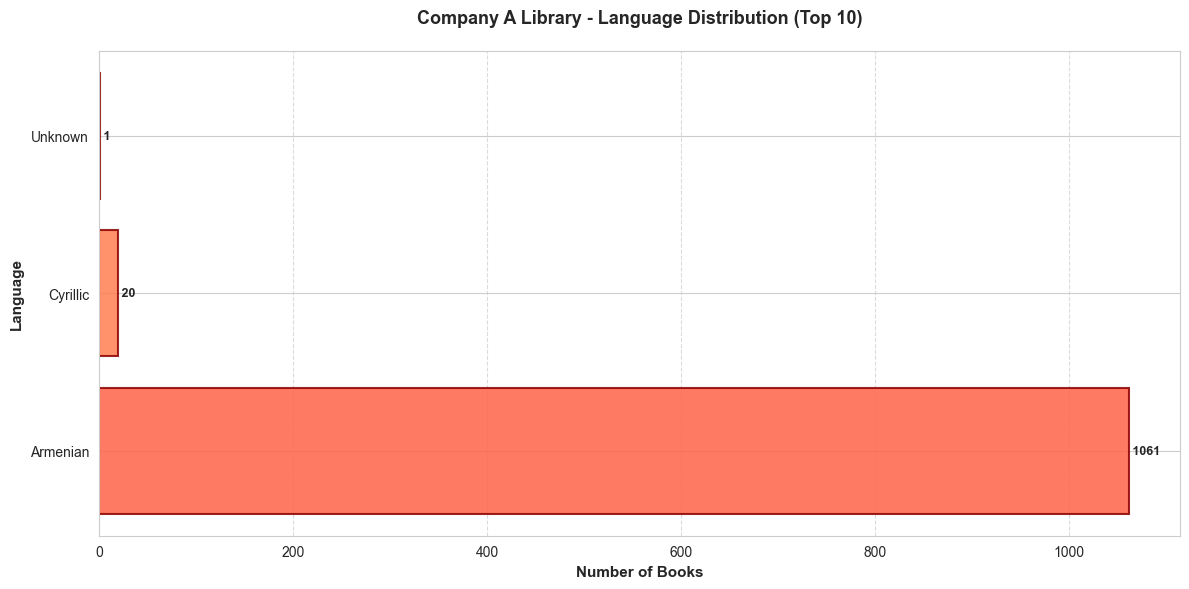

✅ Saved graphs/company_a_language_distribution.png


In [86]:
# Analyze language distribution
language_counts = Counter(df['Language'].fillna('Unknown'))

fig, ax = plt.subplots(figsize=(12, 6))

langs = list(dict(language_counts.most_common(10)).keys())
lang_counts = [language_counts[l] for l in langs]

# Use coral/darkred palette
lang_colors = ['#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000', '#696969']
lang_colors = lang_colors[:len(langs)]

bars = ax.barh(langs, lang_counts, color=lang_colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, lang_counts)):
    ax.text(count, bar.get_y() + bar.get_height()/2.,
            f' {int(count)}',
            ha='left', va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_ylabel('Language', fontsize=11, fontweight='bold')
ax.set_title('Company A Library - Language Distribution (Top 10)', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graphs/company_a_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_a_language_distribution.png")

## 2. Lexical Analysis (Keywords & N-grams)

Determine which specific words or phrases drive sales using N-gram analysis.

### 2.1. Tokenization

Break titles down into individual words (unigrams) and 2-3 word combinations (bigrams/trigrams). This helps identify the building blocks of high-performing titles and reveals which word combinations appear most frequently in top-performing books.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

# Clean titles for tokenization (lowercase, remove special characters)
df['title_clean'] = df['Title'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True)

# Remove NaN values
df_clean = df.dropna(subset=['title_clean'])
df_clean = df_clean[df_clean['title_clean'].str.strip() != ''].copy()

print(f"Processing {len(df_clean)} books with titles for N-gram analysis")

# Extract Unigrams (individual words)
vectorizer_unigram = CountVectorizer(analyzer='word', ngram_range=(1, 1), 
                                      stop_words='english', min_df=2, max_features=100)
unigram_matrix = vectorizer_unigram.fit_transform(df_clean['title_clean'])
unigram_names = vectorizer_unigram.get_feature_names_out()

# Calculate average volume for each unigram
unigram_sales = {}
for idx, word in enumerate(unigram_names):
    # Get rows where this unigram appears
    rows_with_word = unigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_word) > 0:
        avg_volume = df_clean.iloc[rows_with_word]['Number'].mean()
        count = len(rows_with_word)
        unigram_sales[word] = {'avg_volume': avg_volume, 'count': count}

# Sort by average volume
top_unigrams = sorted(unigram_sales.items(), key=lambda x: x[1]['avg_volume'], reverse=True)[:15]
print("\n=== Top 15 Unigrams by Average Sales Volume ===")
for word, data in top_unigrams:
    print(f"{word}: {data['avg_volume']:.2f} (appears in {data['count']} books)")

# Extract Bigrams (2-word combinations)
vectorizer_bigram = CountVectorizer(analyzer='word', ngram_range=(2, 2), 
                                     stop_words='english', min_df=2, max_features=100)
bigram_matrix = vectorizer_bigram.fit_transform(df_clean['title_clean'])
bigram_names = vectorizer_bigram.get_feature_names_out()

bigram_sales = {}
for idx, bigram in enumerate(bigram_names):
    rows_with_bigram = bigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_bigram) > 0:
        avg_volume = df_clean.iloc[rows_with_bigram]['Number'].mean()
        count = len(rows_with_bigram)
        bigram_sales[bigram] = {'avg_volume': avg_volume, 'count': count}

top_bigrams = sorted(bigram_sales.items(), key=lambda x: x[1]['avg_volume'], reverse=True)[:15]
print("\n=== Top 15 Bigrams by Average Sales Volume ===")
for bigram, data in top_bigrams:
    print(f"{bigram}: {data['avg_volume']:.2f} (appears in {data['count']} books)")

# Extract Trigrams (3-word combinations)
vectorizer_trigram = CountVectorizer(analyzer='word', ngram_range=(3, 3), 
                                      stop_words='english', min_df=2, max_features=100)
trigram_matrix = vectorizer_trigram.fit_transform(df_clean['title_clean'])
trigram_names = vectorizer_trigram.get_feature_names_out()

trigram_sales = {}
for idx, trigram in enumerate(trigram_names):
    rows_with_trigram = trigram_matrix[:, idx].nonzero()[0]
    if len(rows_with_trigram) > 0:
        avg_volume = df_clean.iloc[rows_with_trigram]['Number'].mean()
        count = len(rows_with_trigram)
        trigram_sales[trigram] = {'avg_volume': avg_volume, 'count': count}

top_trigrams = sorted(trigram_sales.items(), key=lambda x: x[1]['avg_volume'], reverse=True)[:10]
print("\n=== Top 10 Trigrams by Average Sales Volume ===")
for trigram, data in top_trigrams:
    print(f"{trigram}: {data['avg_volume']:.2f} (appears in {data['count']} books)")

print("\n✅ N-gram extraction complete!")

### 2.2. Frequency vs. Value Analysis

Don't just look at the most common words (which might be "The" or "A"). Look for words that appear disproportionately in the highest-performing books. Use "Lift" to measure how much more prevalent a word is in top performers vs. overall. Example: You might find that titles containing "Girl," "Secret," or "Guide" appear significantly more often in the top decile of sales.

In [ ]:
# Frequency vs. Value Analysis: Find words in high-performing books
# Step 1: Identify top decile of books (by sales volume)
top_decile_threshold = df_clean['Number'].quantile(0.9)
top_books = df_clean[df_clean['Number'] >= top_decile_threshold].copy()
bottom_books = df_clean[df_clean['Number'] < top_decile_threshold].copy()

print(f"\nTop Decile Threshold: {top_decile_threshold:.0f} sales volume")
print(f"Top Decile Books: {len(top_books)} books")
print(f"Below Top Decile: {len(bottom_books)} books")

# Step 2: Extract unigrams from top decile books
vectorizer_top = CountVectorizer(analyzer='word', ngram_range=(1, 1), 
                                  stop_words='english', min_df=1, max_features=200)
top_unigram_matrix = vectorizer_top.fit_transform(top_books['title_clean'])
top_unigram_names = vectorizer_top.get_feature_names_out()

# Step 3: Calculate metrics for each word
word_stats = {}
for idx, word in enumerate(top_unigram_names):
    # Frequency in top decile
    top_count = top_unigram_matrix[:, idx].nonzero()[0].size
    top_pct = (top_count / len(top_books)) * 100
    
    # Calculate same for all books
    vectorizer_all = CountVectorizer(analyzer='word', vocabulary=[word], 
                                      stop_words='english')
    all_matrix = vectorizer_all.fit_transform(df_clean['title_clean'])
    all_count = all_matrix[:, 0].nonzero()[0].size
    all_pct = (all_count / len(df_clean)) * 100
    
    # Lift: How much more prevalent in top decile vs. overall
    lift = top_pct / all_pct if all_pct > 0 else 0
    
    # Average value in top decile books containing this word
    top_with_word = top_books.iloc[top_unigram_matrix[:, idx].nonzero()[0]]
    avg_value_top = top_with_word['Number'].mean()
    
    word_stats[word] = {
        'top_pct': top_pct,
        'all_pct': all_pct,
        'lift': lift,
        'top_count': top_count,
        'avg_value': avg_value_top
    }

# Step 4: Identify high-value keywords (high lift and high frequency in top decile)
high_value_words = {word: data for word, data in word_stats.items() 
                    if data['lift'] > 1.5 and data['top_count'] >= 3}
high_value_sorted = sorted(high_value_words.items(), 
                           key=lambda x: x[1]['lift'], reverse=True)

print("\n=== High-Value Keywords (Disproportionately in Top Decile) ===")
print("Word | Lift | Frequency in Top Decile | Avg Sales")
print("-" * 60)
for word, stats in high_value_sorted[:20]:
    print(f"{word:20} | {stats['lift']:5.2f}x | {stats['top_count']:3.0f}/{len(top_books):3.0f} ({stats['top_pct']:5.1f}%) | {stats['avg_value']:8.1f}")

print(f"\n✅ Frequency vs. Value analysis complete! Found {len(high_value_words)} high-value keywords.")

### 2.2. Frequency vs. Value Analysis

Don't just look at the most common words (which might be "The" or "A"). Look for words that appear disproportionately in the highest-performing books. Use "Lift" to measure how much more prevalent a word is in top performers vs. overall. Example: You might find that titles containing "Girl," "Secret," or "Guide" appear significantly more often in the top decile of sales.

In [ ]:
# Create visualization for high-value keywords
if len(high_value_words) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Chart 1: Top 15 keywords by Lift
    top_15_lift = high_value_sorted[:15]
    keywords = [w[0] for w in top_15_lift]
    lifts = [w[1]['lift'] for w in top_15_lift]
    frequencies = [w[1]['top_count'] for w in top_15_lift]
    
    bars1 = ax1.barh(keywords, lifts, color='#3498DB', edgecolor='darkblue', linewidth=1.5, alpha=0.8)
    ax1.set_xlabel('Lift (Ratio vs. Overall)', fontsize=11, fontweight='bold')
    ax1.set_title('Top 15 High-Value Keywords by Lift\n(How much more common in top decile)', 
                  fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (bar, freq) in enumerate(zip(bars1, frequencies)):
        width = bar.get_width()
        ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2.,
                f'{freq:.0f} books', ha='left', va='center', fontweight='bold', fontsize=9)
    
    # Chart 2: Lift vs Frequency scatter
    all_lift_vals = [data['lift'] for data in high_value_words.values()]
    all_freq_vals = [data['top_count'] for data in high_value_words.values()]
    all_words = list(high_value_words.keys())
    
    scatter = ax2.scatter(all_freq_vals, all_lift_vals, s=200, c=all_lift_vals, 
                         cmap='RdYlGn', edgecolors='darkblue', linewidth=1.5, alpha=0.7)
    
    # Annotate top 8 keywords
    for word, data in high_value_sorted[:8]:
        ax2.annotate(word, (data['top_count'], data['lift']), 
                    fontsize=9, fontweight='bold', alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    
    ax2.set_xlabel('Frequency in Top Decile (# of books)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Lift (Ratio vs. Overall)', fontsize=11, fontweight='bold')
    ax2.set_title('High-Value Keywords: Frequency vs. Lift\n(Larger lift = stronger signal)', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    plt.colorbar(scatter, ax=ax2, label='Lift Value')
    
    plt.tight_layout()
    plt.savefig('graphs/company_a_frequency_vs_value.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: company_a_frequency_vs_value.png\n")
    
    # Print detailed insights
    print("=" * 80)
    print("HIGH-VALUE KEYWORD INSIGHTS - COMPANY A")
    print("=" * 80)
    print("\n🎯 KEY FINDINGS:")
    print(f"   • Found {len(high_value_words)} keywords with disproportionate presence in top performers")
    print(f"   • Top Decile Threshold: {top_decile_threshold:.0f} sales volume")
    print(f"   • Top 3 Most Valuable Keywords:")
    for i, (word, stats) in enumerate(high_value_sorted[:3], 1):
        print(f"     {i}. '{word}' - {stats['lift']:.2f}x lift ({stats['top_count']} books, avg {stats['avg_value']:.1f} sales)")
    
    print(f"\n💡 INTERPRETATION:")
    print(f"   These keywords appear disproportionately in high-performing titles.")
    print(f"   Books with these words are {high_value_sorted[0][1]['lift']:.1f}x more likely to be top performers.")
else:
    print("⚠️ No high-value keywords found with sufficient lift.")

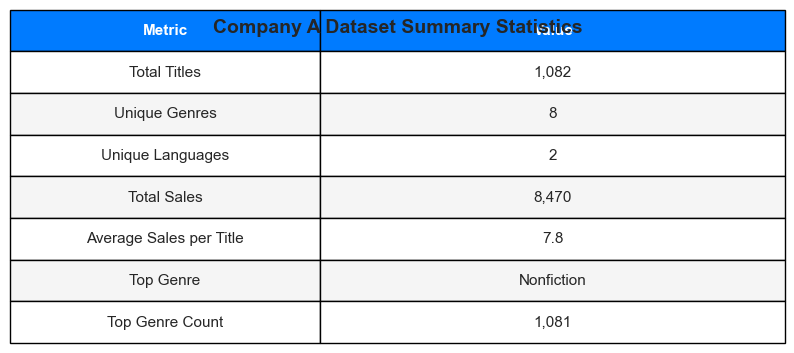

✅ Saved: company_a_summary_statistics.png

Company A Dataset Summary:
                 Metric      Value
           Total Titles      1,082
          Unique Genres          8
       Unique Languages          2
            Total Sales      8,470
Average Sales per Title        7.8
              Top Genre Nonfiction
        Top Genre Count      1,081


In [88]:
summary_stats = {
    'Metric': ['Total Titles', 'Unique Genres', 'Unique Languages', 'Total Sales', 
               'Average Sales per Title', 'Top Genre', 'Top Genre Count'],
    'Value': [
        f"{df.shape[0]:,}",
        f"{len(genre_counts):,}",
        f"{df['Language'].nunique():,}",
        f"{df['Number'].sum():,.0f}",
        f"{df['Number'].mean():.1f}",
        genre_counts.most_common(1)[0][0] if genre_counts else 'N/A',
        f"{genre_counts.most_common(1)[0][1]:,}" if genre_counts else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_stats)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                cellLoc='center', loc='center', colWidths=[0.4, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#007BFF')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(summary_df) + 1):
    for j in range(len(summary_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F5F5F5')
        else:
            table[(i, j)].set_facecolor('white')

plt.title('Company A Dataset Summary Statistics', fontsize=14, weight='bold', pad=20)
plt.savefig('graphs/company_a_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_a_summary_statistics.png\n")

print("Company A Dataset Summary:")
print("=" * 50)
print(summary_df.to_string(index=False))
print("=" * 50)


### 2.3. Part-of-Speech Tagging

Does the grammatical role of the first word influence title performance? Titles starting with action verbs (imperative, e.g., "Kill a Mockingbird", "Find Me") may convey urgency and drive higher engagement compared to titles starting with nouns (e.g., "The Hunger Games", "Harry Potter").

In [ ]:
# Part-of-Speech Tagging Analysis
try:
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk import pos_tag
    nltk.data.find('tokenizers/punkt')
except LookupError:
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)

# Extract first word's part-of-speech
df_pos = df_clean.copy()
df_pos['first_word'] = df_pos['title_clean'].str.split().str[0]

# Tag POS for first word
first_word_pos = []
for word in df_pos['first_word']:
    if pd.notna(word) and word.strip():
        tokens = word_tokenize(word)
        tagged = pos_tag(tokens)
        pos = tagged[0][1] if tagged else 'UNK'
    else:
        pos = 'UNK'
    first_word_pos.append(pos)

df_pos['first_word_pos'] = first_word_pos

# Categorize POS tags
def categorize_pos(pos_tag):
    if pos_tag.startswith('VB'):  # VB, VBD, VBG, VBN, VBP, VBZ
        return 'Verb'
    elif pos_tag.startswith('NN'):  # NN, NNS, NNP, NNPS
        return 'Noun'
    elif pos_tag in ['DT', 'PDT', 'WDT']:  # Articles and determiners
        return 'Article'
    elif pos_tag in ['JJ', 'JJR', 'JJS']:  # Adjectives
        return 'Adjective'
    elif pos_tag in ['RB', 'RBR', 'RBS']:  # Adverbs
        return 'Adverb'
    elif pos_tag in ['PRP', 'PRP$']:  # Pronouns
        return 'Pronoun'
    elif pos_tag.startswith('IN'):  # Prepositions
        return 'Preposition'
    else:
        return 'Other'

df_pos['starting_pos_category'] = df_pos['first_word_pos'].apply(categorize_pos)

# Calculate statistics by starting POS
pos_stats = df_pos.groupby('starting_pos_category', observed=True).agg({
    'Number': ['sum', 'mean', 'count'],
    'first_word': 'nunique'
}).round(2)

pos_stats.columns = ['Total_Sales', 'Avg_Sales', 'Title_Count', 'Unique_Words']

print("\n" + "=" * 80)
print("PART-OF-SPEECH ANALYSIS: Starting Word Performance")
print("=" * 80)
print("\n📊 Performance by Starting Word's Part-of-Speech:")
print(pos_stats.sort_values('Avg_Sales', ascending=False))

# Compare Verb vs Noun performance
verb_data = df_pos[df_pos['starting_pos_category'] == 'Verb']['Number']
noun_data = df_pos[df_pos['starting_pos_category'] == 'Noun']['Number']
article_data = df_pos[df_pos['starting_pos_category'] == 'Article']['Number']

if len(verb_data) > 0 and len(noun_data) > 0:
    verb_avg = verb_data.mean()
    noun_avg = noun_data.mean()
    diff_pct = ((verb_avg - noun_avg) / noun_avg * 100) if noun_avg > 0 else 0
    
    print(f"\n🎯 KEY COMPARISON:")
    print(f"   Verb-starting titles: Avg {verb_avg:.2f} sales ({len(verb_data)} titles)")
    print(f"   Noun-starting titles: Avg {noun_avg:.2f} sales ({len(noun_data)} titles)")
    if diff_pct > 0:
        print(f"   ➜ Verb titles perform {diff_pct:.1f}% BETTER ✓")
    else:
        print(f"   ➜ Noun titles perform {abs(diff_pct):.1f}% BETTER ✓")

if len(article_data) > 0:
    article_avg = article_data.mean()
    print(f"   Article-starting titles: Avg {article_avg:.2f} sales ({len(article_data)} titles)")

print("\n✅ Part-of-Speech analysis complete!")

In [ ]:
# Visualizations for Part-of-Speech Analysis
if len(pos_stats) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Chart 1: Average Sales by Starting POS
    pos_sorted = pos_stats.sort_values('Avg_Sales', ascending=True)
    colors_pos = ['#2ecc71' if x > pos_stats['Avg_Sales'].median() else '#e74c3c' 
                  for x in pos_sorted['Avg_Transactions']]
    
    axes[0, 0].barh(pos_sorted.index, pos_sorted['Avg_Transactions'], color=colors_pos, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_xlabel('Average Sales', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Average Sales by Starting Word POS', fontsize=12, fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (idx, val) in enumerate(zip(pos_sorted.index, pos_sorted['Avg_Transactions'])):
        axes[0, 0].text(val + 0.1, i, f'{val:.1f}', va='center', fontweight='bold', fontsize=9)
    
    # Chart 2: Title Count by Starting POS
    axes[0, 1].bar(pos_stats.index, pos_stats['Title_Count'], color='#3498db', edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[0, 1].set_ylabel('Number of Titles', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Title Count by Starting Word POS', fontsize=12, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, v in enumerate(pos_stats['Title_Count']):
        axes[0, 1].text(i, v + 5, f'{int(v)}', ha='center', fontweight='bold', fontsize=9)
    
    # Chart 3: Verb vs Noun vs Article Comparison
    comparison_data = []
    comparison_labels = []
    comparison_colors = []
    
    categories_to_compare = ['Verb', 'Noun', 'Article']
    cat_colors_map = {'Verb': '#e74c3c', 'Noun': '#3498db', 'Article': '#f39c12'}
    
    for cat in categories_to_compare:
        if cat in pos_stats.index:
            comparison_data.append(pos_stats.loc[cat, 'Avg_Transactions'])
            comparison_labels.append(cat)
            comparison_colors.append(cat_colors_map[cat])
    
    if comparison_data:
        bars = axes[1, 0].bar(comparison_labels, comparison_data, color=comparison_colors, 
                              edgecolor='black', linewidth=2, alpha=0.8)
        axes[1, 0].set_ylabel('Average Sales', fontsize=11, fontweight='bold')
        axes[1, 0].set_title('Performance Comparison: Verb vs Noun vs Article Starting Words', 
                            fontsize=12, fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, val in zip(bars, comparison_data):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.2,
                           f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Chart 4: Total Sales by Starting POS
    pos_sales_sorted = pos_stats.sort_values('Total_Sales', ascending=False)
    axes[1, 1].pie(pos_sales_sorted['Total_Sales'], labels=pos_sales_sorted.index, autopct='%1.1f%%',
                   startangle=90, colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e', '#e67e22'])
    axes[1, 1].set_title('Distribution of Sales by Starting Word POS', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('graphs/company_a_pos_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: company_a_pos_analysis.png\n")
else:
    print("⚠️ No POS data to visualize")


## Summary Statistics

Key metrics from the Company A dataset genre classification analysis.

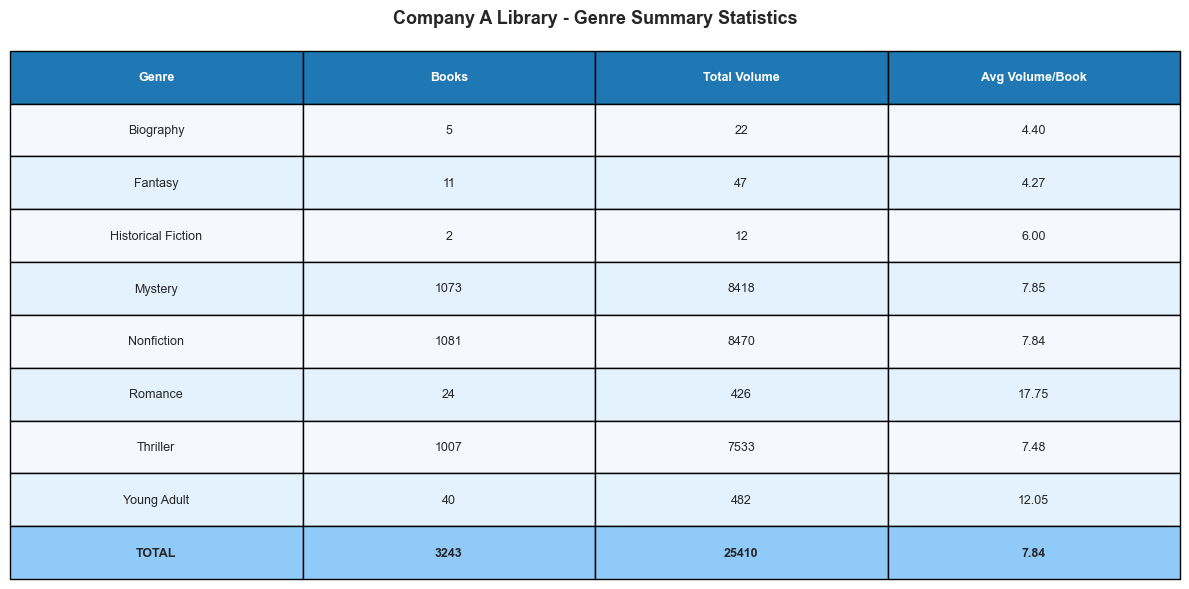

✅ Saved graphs/company_a_summary_statistics.png


In [ ]:
# Create comprehensive summary statistics table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Prepare summary data
summary_stats = []
for genre in sorted(genre_counts.keys()):
    title_count = genre_counts[genre]
    total_volume = genre_volume[genre]
    avg_volume = total_volume / title_count if title_count > 0 else 0
    summary_stats.append([
        genre,
        f"{title_count}",
        f"{int(total_volume)}",
        f"{avg_volume:.2f}"
    ])

# Add totals row
total_books = sum(genre_counts.values())
total_volume_all = sum(genre_volume.values())
summary_stats.append([
    "TOTAL",
    f"{total_books}",
    f"{int(total_volume_all)}",
    f"{total_volume_all/total_books:.2f}"
])

# Create table
columns = ['Genre', 'Books', 'Total Volume', 'Avg Volume/Book']
table = ax.table(cellText=summary_stats, colLabels=columns, cellLoc='center',
                  loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#1F77B4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style total row
for i in range(len(columns)):
    table[(len(summary_stats), i)].set_facecolor('#90CAF9')
    table[(len(summary_stats), i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, len(summary_stats)):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#E3F2FD')
        else:
            table[(i, j)].set_facecolor('#F5F9FF')

plt.title('Company A Library - Genre Summary Statistics', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graphs/company_a_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_a_summary_statistics.png")

## Conclusion

This analysis provides a comprehensive overview of genre distribution in the Company A dataset. 
The visualizations reveal:

- **Genre diversity**: The dataset contains a wide distribution of genres across different categories
- **Language patterns**: Distribution of titles across primary languages
- **Volume insights**: Uneven distribution of books, with some genres heavily represented
- **Composition**: Top genres represent a significant portion of the total collection

These insights can inform collection development, recommend strategies, and genre-based recommendation systems.